In [24]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM hospital_performance_final", engine)

In [26]:
# Segmentación del hpi usando z-score
hpi_mean = df["hpi"].mean()
hpi_std = df["hpi"].std()
df["hpi_zscore"] = (df["hpi"] - hpi_mean) / hpi_std

df["hpi_class"] = pd.cut(
    df["hpi_zscore"],
    bins=[-float("inf"), -1.0, 1.0, float("inf")],
    labels=["low", "medium", "high"]
)

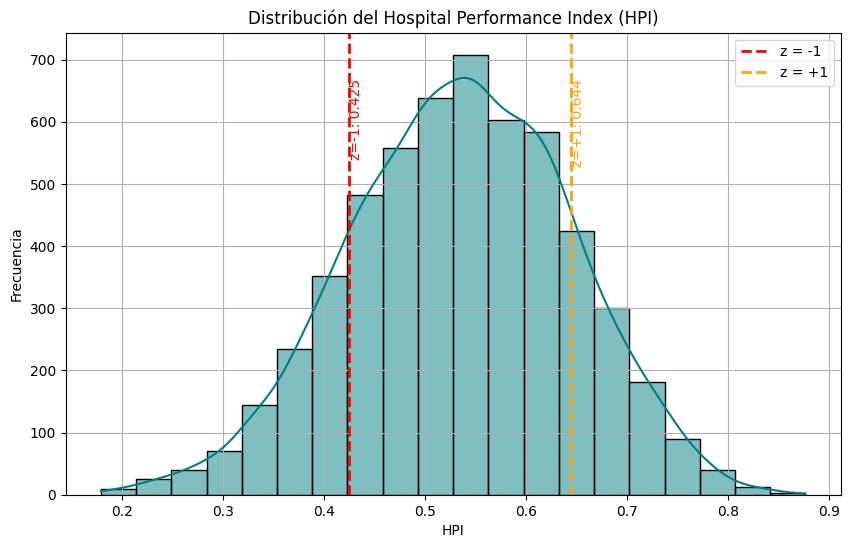

In [27]:
# Histograma del HPI con separación por z-score
plt.figure(figsize=(10, 6))
sns.histplot(df['hpi'], bins=20, kde=True, color='teal')

low_medium = hpi_mean - hpi_std
medium_high = hpi_mean + hpi_std

plt.axvline(low_medium, color='red', linestyle='--', linewidth=2, label='z = -1')
plt.axvline(medium_high, color='orange', linestyle='--', linewidth=2, label='z = +1')

ymax = plt.gca().get_ylim()[1]
plt.text(low_medium, ymax * 0.9, f'z=-1: {low_medium:.3f}', color='red', rotation=90, va='top')
plt.text(medium_high, ymax * 0.9, f'z=+1: {medium_high:.3f}', color='orange', rotation=90, va='top')

plt.legend()
plt.title('Distribución del Hospital Performance Index (HPI)')
plt.xlabel('HPI')
plt.ylabel('Frecuencia')
plt.grid()
plt.show()

In [28]:
# crear subconjuntos según la nueva clasificación por z-score
hpi_bajo = df[df['hpi_class']=='low'].copy()
hpi_medio = df[df['hpi_class']=='medium'].copy()
hpi_alto = df[df['hpi_class']=='high'].copy()

In [29]:
# Configuración que permite mostrar todas las columnas
pd.set_option('display.max_columns', None)

In [30]:
hpi_bajo.shape[0]

900

In [31]:
hpi_medio.shape[0]

3721

In [32]:
hpi_alto.shape[0]

879

In [40]:
hpi_bajo.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,9.000000e+02,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,2023.045556,783.895556,101.878889,10.726667,6.543333,204.307778,77.153333,404.597778,153.461111,0.001244,1570.925556,746.447778,206.785556,7.109667,418.513333,28683.467778,2202.141111,130200.455556,5.957324e+06,6.583556,3.375422,4.682833,6.760011,121.246667,20.060444,43.078889,1595.807148,0.037778,0.233589,0.250042,34.684331,762.366667,0.929462,0.357364,0.337887,0.430391,0.366113,-1.537400
std,0.823144,420.417601,57.664788,5.747830,1.428671,113.112413,43.428548,225.021359,82.490365,0.000438,850.561543,426.734345,114.276131,2.265489,230.005535,14963.985396,1476.407732,84982.922154,1.270455e+07,1.134295,1.190349,1.682033,2.425564,43.502845,11.238758,22.062138,850.525880,0.190764,0.327968,0.427688,47.908131,262.390603,1.461006,0.117367,0.177809,0.302459,0.050789,0.463214
min,2022.000000,52.000000,5.000000,1.000000,4.000000,11.000000,5.000000,20.000000,10.000000,0.000501,53.000000,24.000000,6.000000,1.500000,11.000000,846.000000,100.000000,5065.000000,0.000000e+00,5.000000,0.540000,0.530000,1.070000,6.000000,1.100000,5.000000,54.333333,0.000000,0.003340,0.004482,0.388889,82.000000,0.038740,0.069000,0.023000,0.000000,0.179000,-3.243928
25%,2022.000000,417.750000,50.000000,6.000000,5.400000,104.750000,39.000000,216.000000,80.750000,0.000857,845.500000,396.750000,109.750000,5.500000,224.750000,13951.750000,759.500000,54911.000000,0.000000e+00,5.700000,2.520000,3.577500,4.970000,92.000000,10.550000,24.000000,857.316667,0.000000,0.063938,0.067097,9.764706,574.000000,0.314045,0.272500,0.195000,0.153000,0.339000,-1.784682
50%,2023.000000,792.500000,105.500000,11.000000,6.500000,204.000000,77.000000,399.000000,151.000000,0.001253,1640.000000,731.500000,208.500000,7.600000,428.500000,31300.500000,2025.500000,113437.500000,0.000000e+00,6.400000,3.660000,4.955000,7.280000,129.000000,19.500000,44.000000,1660.216667,0.000000,0.128506,0.125240,19.617647,761.500000,0.473506,0.350000,0.327000,0.377000,0.380000,-1.410750
75%,2024.000000,1139.000000,150.000000,16.000000,7.800000,302.000000,116.000000,597.250000,225.250000,0.001635,2287.000000,1127.500000,311.000000,9.000000,617.500000,42411.250000,3469.000000,204210.500000,0.000000e+00,7.300000,4.380000,6.080000,8.860000,158.000000,29.900000,62.250000,2318.733333,0.000000,0.232167,0.248930,39.000000,950.000000,0.882731,0.434000,0.469250,0.728000,0.405000,-1.182742
max,2024.000000,1499.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,2992.000000,1500.000000,398.000000,10.000000,799.000000,49977.000000,4990.000000,299685.000000,4.990293e+07,9.400000,5.000000,6.990000,10.000000,180.000000,40.000000,80.000000,3022.366667,1.000000,2.821429,4.621057,391.000000,1448.000000,15.773006,0.721000,0.893000,0.993000,0.425000,-1.000337


In [34]:
hpi_medio.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3.721000e+03,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000,3721.000000
mean,2022.979844,774.871809,104.016662,10.488847,6.509325,204.616501,77.804891,406.064230,153.610857,0.001256,1495.830959,755.502016,202.553077,5.751169,407.198334,15862.739317,1564.787691,99410.780167,1.287039e+07,7.310427,2.764862,3.833381,5.478780,93.420317,20.672292,43.050793,1521.014360,0.041655,0.246047,0.265343,36.136330,764.291588,0.997729,0.499911,0.497313,0.689534,0.537056,0.021648
std,0.819370,423.328964,56.820451,5.747084,1.436308,113.349101,41.846726,225.251742,85.383431,0.000432,847.745636,426.216673,114.525167,2.385728,227.642372,12667.461110,1479.905992,82775.374511,1.606588e+07,1.274598,1.290792,1.851744,2.552394,49.209003,11.341122,21.722538,847.961206,0.199827,0.353919,0.446387,53.725864,265.619675,1.539083,0.122474,0.186521,0.256044,0.060091,0.548044
min,2022.000000,50.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000500,50.000000,20.000000,5.000000,1.500000,10.000000,507.000000,100.000000,5052.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.000000,5.000000,57.400000,0.000000,0.003569,0.003287,0.263158,96.000000,0.036312,0.123000,0.003000,0.000000,0.426000,-0.991216
25%,2022.000000,402.000000,56.000000,6.000000,5.300000,108.000000,41.000000,213.000000,78.000000,0.000886,746.000000,388.000000,105.000000,3.800000,213.000000,6507.000000,430.000000,38182.000000,0.000000e+00,6.200000,1.650000,2.250000,3.330000,54.000000,10.600000,25.000000,774.466667,0.000000,0.070555,0.070265,9.421053,566.000000,0.326920,0.418000,0.367000,0.534000,0.488000,-0.425758
50%,2023.000000,774.000000,104.000000,10.000000,6.500000,204.000000,78.000000,404.000000,153.000000,0.001257,1491.000000,748.000000,205.000000,5.800000,404.000000,11682.000000,736.000000,66592.000000,2.834207e+06,7.400000,2.770000,3.870000,5.460000,93.000000,21.100000,43.000000,1518.066667,0.000000,0.132544,0.135322,19.181818,766.000000,0.499225,0.495000,0.499000,0.774000,0.538000,0.030256
75%,2024.000000,1143.000000,154.000000,15.000000,7.700000,303.000000,114.000000,601.000000,229.000000,0.001633,2226.000000,1128.000000,304.000000,7.700000,604.000000,23557.000000,2698.000000,152398.000000,2.516234e+07,8.400000,3.880000,5.430000,7.670000,135.000000,30.400000,62.000000,2255.366667,0.000000,0.257576,0.260997,37.250000,967.000000,0.969609,0.584000,0.627000,0.879000,0.588000,0.486271
max,2024.000000,1500.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.002000,3000.000000,1500.000000,400.000000,10.000000,800.000000,49964.000000,4995.000000,299953.000000,4.998359e+07,9.500000,5.000000,7.000000,10.000000,180.000000,40.000000,80.000000,3042.900000,1.000000,3.316667,5.705128,399.000000,1474.000000,19.616725,0.931000,0.994000,1.000000,0.644000,0.997007


In [35]:
hpi_alto.describe()

,year,total_beds,icu_beds,operation_theatres,medical_equipment_score,total_doctors,specialists,nurses,paramedical_staff,doctor_patient_ratio,daily_outpatients,monthly_admissions,surgeries_per_month,average_length_of_stay,emergency_cases,average_treatment_cost,consultation_fee,surgery_cost,government_funding,patient_satisfaction_score,mortality_rate,infection_rate,readmission_rate,waiting_time_minutes,distance_from_city_center,rural_patients_percentage,estimated_daily_load,icu_inconsistency_flag,icu_bed_ratio,doctor_per_patient_ratio,surgeries_per_theatre,total_staff,staff_per_patient_ratio,quality_score,efficiency_score,cost_score,hpi,hpi_zscore
count,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.00000,879.000000,879.000000,8.790000e+02,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000,879.000000
mean,2022.997725,785.741752,100.457338,10.698521,6.390671,201.852105,80.188851,415.326507,149.980660,0.001258,1530.397042,762.417520,202.878271,4.104892,402.118316,9209.62116,1080.511945,74691.478953,1.837144e+07,8.010466,2.121536,2.777873,4.065222,61.923777,20.052673,41.913538,1555.810959,0.042093,0.236014,0.257987,36.406284,767.159272,1.003955,0.654420,0.684133,0.824015,0.697231,1.482489
std,0.829411,416.784964,56.687230,5.859314,1.433382,113.179835,42.416186,232.279913,84.251053,0.000437,829.097883,424.331265,115.807760,2.099536,232.494822,7088.79827,1252.128989,67385.953631,1.674743e+07,1.139688,1.208830,1.703359,2.318023,44.315496,11.331017,21.668801,828.650714,0.200916,0.374906,0.453820,54.777470,268.808617,1.624591,0.107386,0.164721,0.143274,0.041859,0.381770
min,2022.000000,51.000000,5.000000,1.000000,4.000000,10.000000,5.000000,20.000000,10.000000,0.000502,52.000000,22.000000,5.000000,1.500000,10.000000,502.00000,101.000000,5068.000000,0.000000e+00,5.000000,0.500000,0.500000,1.000000,5.000000,1.100000,5.000000,69.033333,0.000000,0.004216,0.004105,0.350000,116.000000,0.076715,0.338000,0.126000,0.069000,0.645000,1.006127
25%,2022.000000,422.000000,50.000000,5.000000,5.200000,102.000000,44.000000,215.000000,75.500000,0.000886,881.500000,399.500000,101.000000,2.400000,196.000000,4189.00000,331.500000,31751.500000,0.000000e+00,7.200000,1.060000,1.325000,2.085000,24.000000,9.700000,24.000000,899.383333,0.000000,0.065052,0.067219,9.083333,561.000000,0.325330,0.576000,0.559000,0.767500,0.663000,1.170292
50%,2023.000000,786.000000,101.000000,11.000000,6.400000,204.000000,82.000000,412.000000,150.000000,0.001261,1546.000000,768.000000,202.000000,3.500000,402.000000,7909.00000,580.000000,53554.000000,1.598901e+07,8.300000,1.870000,2.400000,3.510000,52.000000,19.900000,41.000000,1575.133333,0.000000,0.127660,0.127989,18.687500,767.000000,0.495936,0.655000,0.701000,0.850000,0.688000,1.398300
75%,2024.000000,1155.000000,150.000000,16.000000,7.600000,296.500000,118.000000,624.000000,221.000000,0.001642,2203.000000,1117.000000,307.000000,5.400000,610.500000,12016.00000,867.000000,77318.000000,3.357278e+07,9.000000,2.940000,4.060000,5.620000,88.500000,29.700000,61.000000,2237.883333,0.000000,0.231744,0.248847,35.850000,974.500000,0.896377,0.730000,0.815000,0.925500,0.722000,1.708390
max,2024.000000,1499.000000,200.000000,20.000000,9.000000,400.000000,150.000000,800.000000,300.000000,0.001999,2991.000000,1500.000000,400.000000,10.000000,799.000000,46544.00000,4902.000000,297218.000000,4.991739e+07,9.500000,5.000000,6.970000,9.840000,179.000000,39.900000,80.000000,3025.300000,1.000000,3.462963,5.256065,390.000000,1361.000000,15.540797,0.954000,0.997000,1.000000,0.877000,3.122035


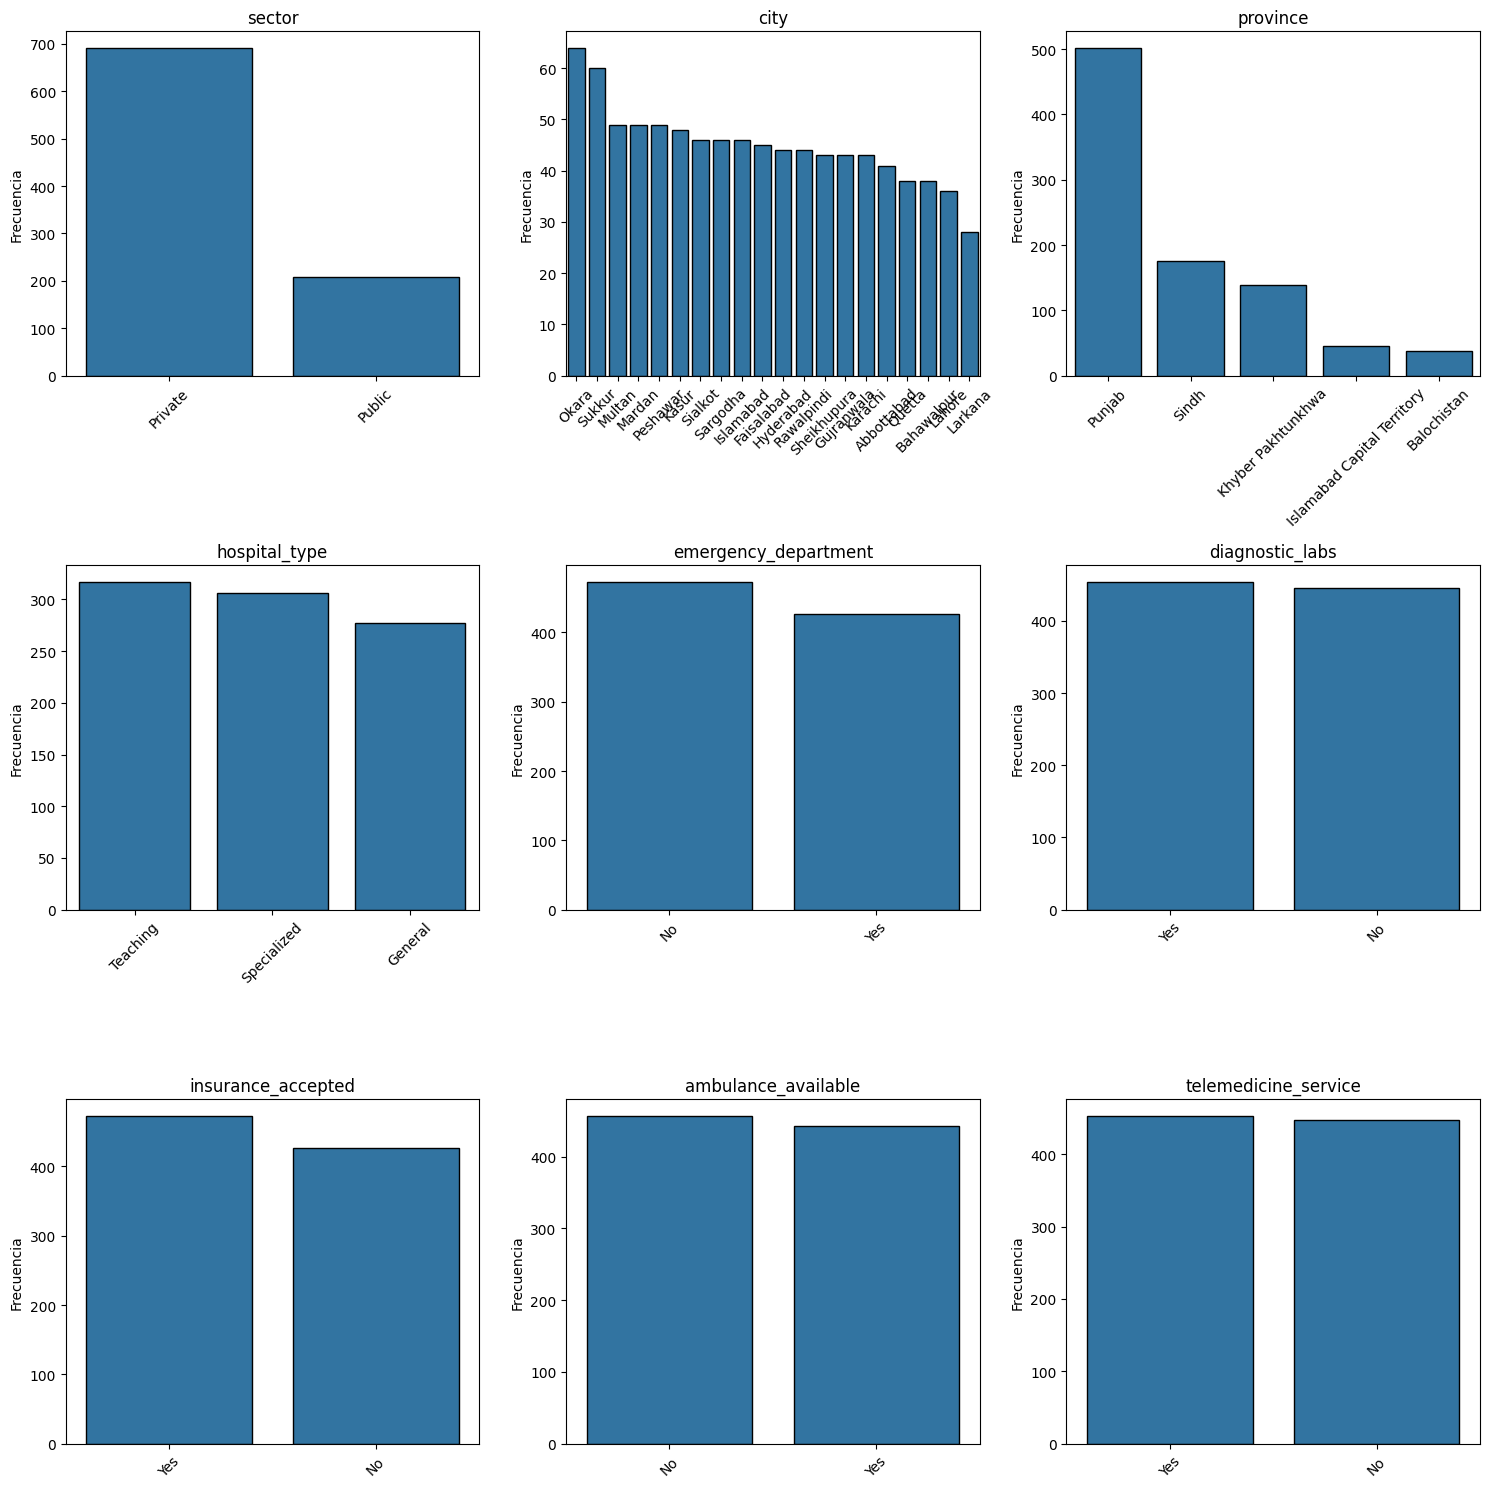

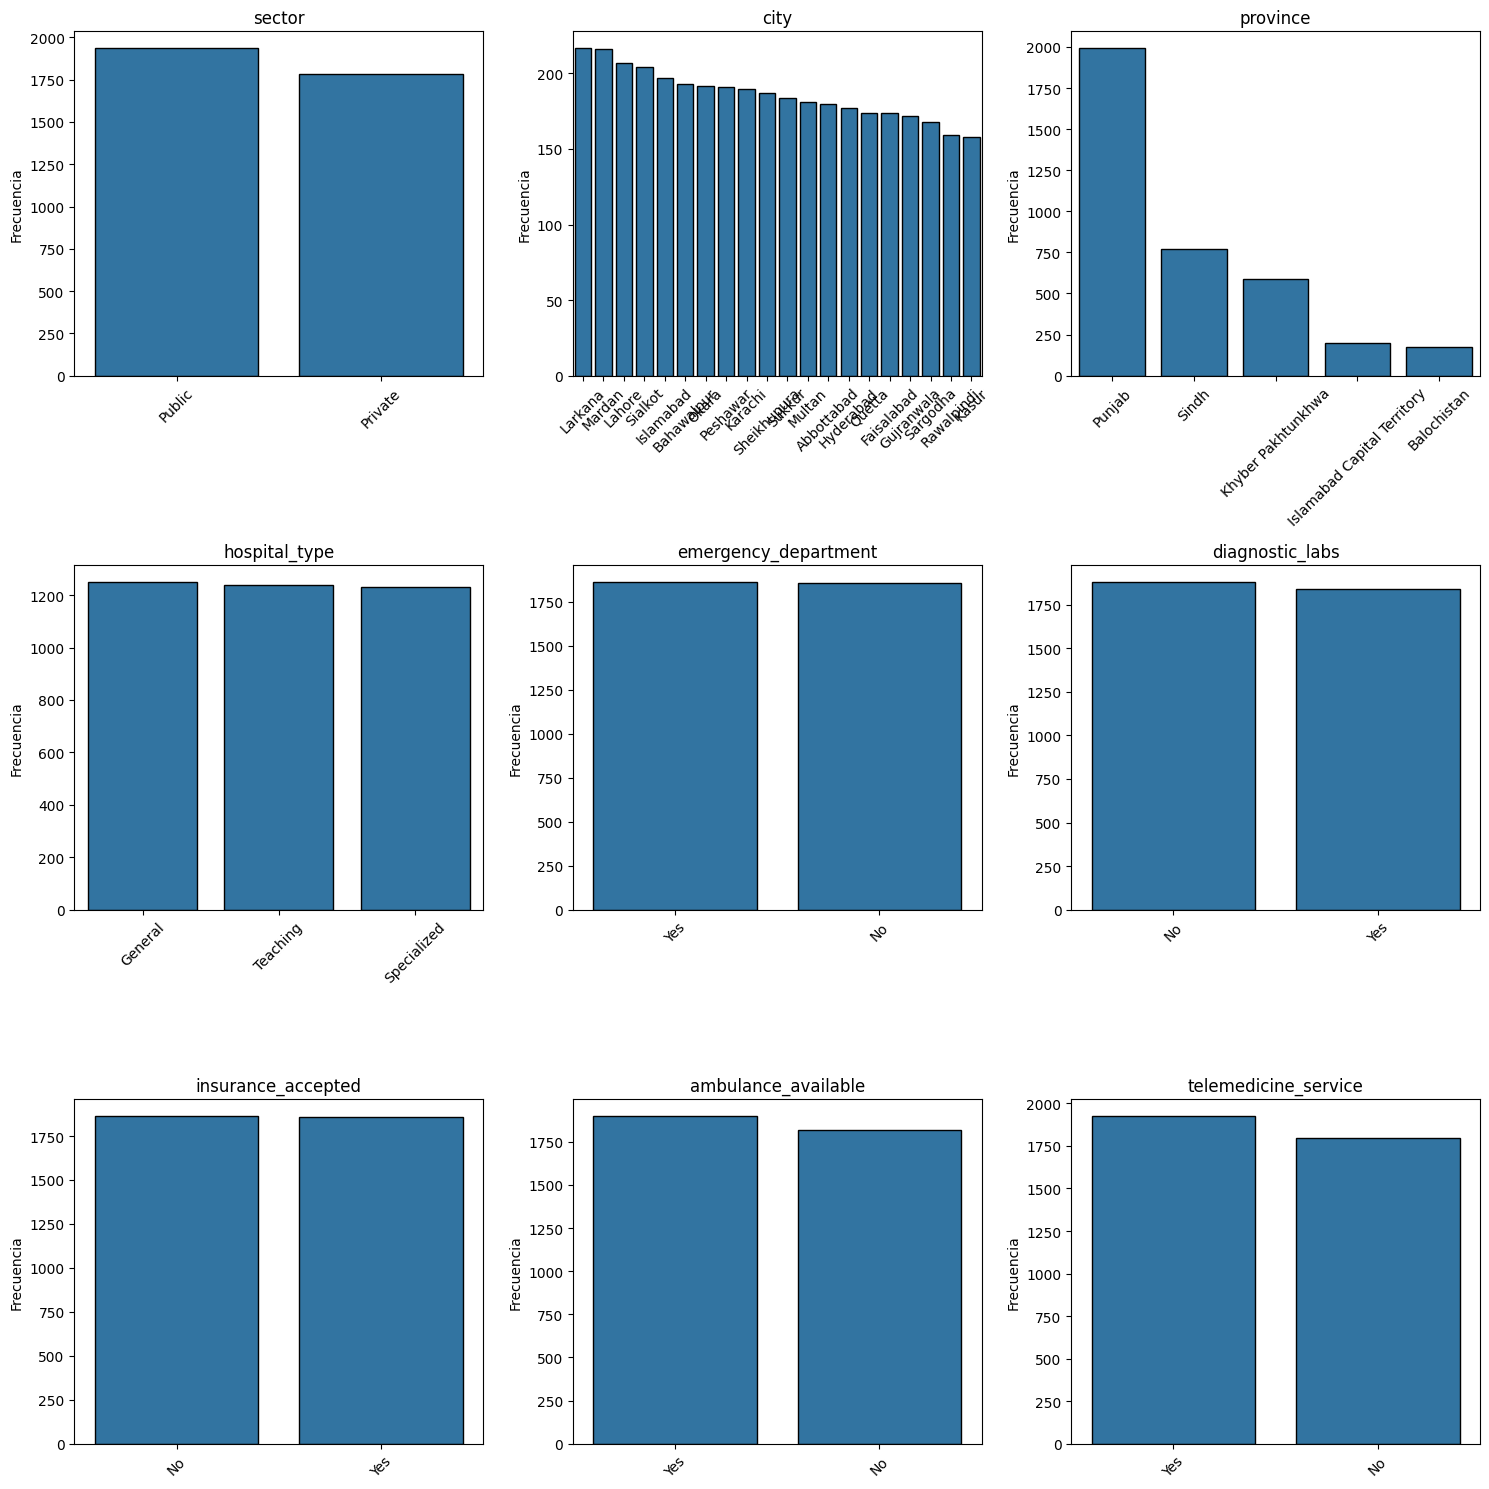

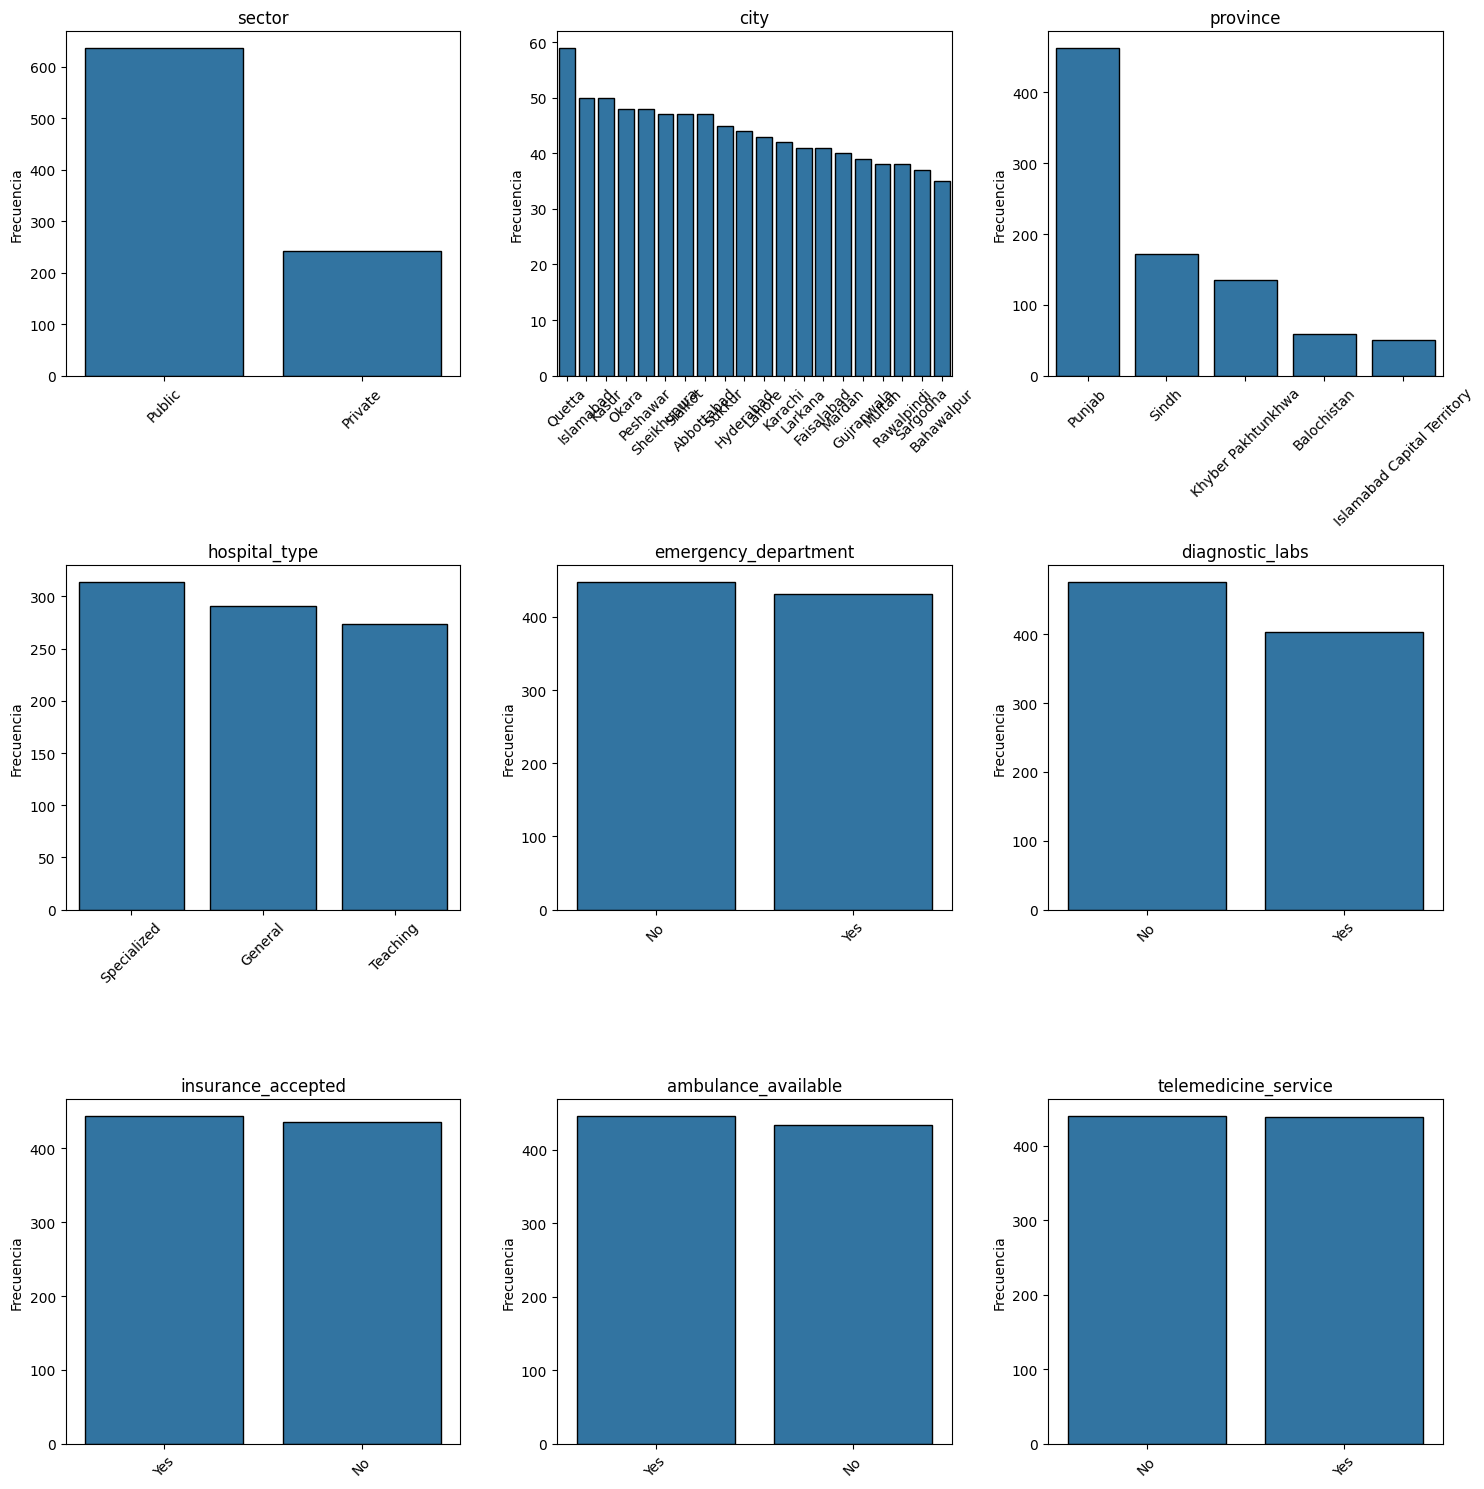

In [36]:
import math

# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 30  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

for df in [hpi_bajo, hpi_medio, hpi_alto]:
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()  # simplifica indexado

    for i, col in enumerate(cat_cols):
        ax = axes[i]

        value_counts = df[col].value_counts()

        sns.barplot(x=value_counts.index, y=value_counts.values, edgecolor="black", ax=ax)

        ax.set_title(col)
        ax.set_xlabel("")
        ax.set_ylabel("Frecuencia")
        ax.tick_params(axis="x", rotation=45)

    # eliminar ejes vacíos (si sobran)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()